In [ ]:
# ============================================================
# CELL 1: GPU CHECK
# Before anything else verify GPU is available
# Runtime → Change runtime type → T4 GPU
# ============================================================

import torch
import sys

print("=" * 60)
print("  LIVESTOCK GUARDIAN — SYSTEM CHECK")
print("=" * 60)

print(f"\nPython Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_de
    vice_properties(0).total_mem / 1e9
    print(f"GPU Memory: {mem:.1f} GB")
    print("\n✅ GPU Ready — Proceed to next cell")
else:
    print("\n❌ NO GPU FOUND")
    print("Fix: Runtime → Change runtime type → T4 GPU → Save")
    print("Then run this cell again")

  LIVESTOCK GUARDIAN — SYSTEM CHECK

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch Version: 2.11.0+cpu
GPU Available: False

❌ NO GPU FOUND
Fix: Runtime → Change runtime type → T4 GPU → Save
Then run this cell again


In [ ]:
# ============================================================
# CELL 2: INSTALL ALL REQUIRED LIBRARIES
# All FREE — no paid subscriptions needed
# ============================================================

print("Installing libraries...")

!pip install timm --quiet
!pip install onnx onnxruntime --quiet
!pip install python-multipart --quiet
!pip install seaborn --quiet
!pip install scikit-learn --quiet

# Verify all installed
import torch
import torchvision
import timm
import onnx
import onnxruntime
import sklearn
import seaborn
import numpy
import PIL
import cv2
import matplotlib

print("\n✅ All libraries installed!")
print(f"  torch:        {torch.__version__}")
print(f"  torchvision:  {torchvision.__version__}")
print(f"  onnx:         {onnx.__version__}")
print(f"  onnxruntime:  {onnxruntime.__version__}")
print(f"  sklearn:      {sklearn.__version__}")

Installing libraries...

✅ All libraries installed!
  torch:        2.11.0+cpu
  torchvision:  0.26.0+cpu
  onnx:         1.21.0
  onnxruntime:  1.26.0
  sklearn:      1.6.1


In [ ]:
# ============================================================
# CELL 3: MOUNT GOOGLE DRIVE + CREATE ALL FOLDERS
# Drive saves everything permanently
# Even if Colab disconnects — your work is safe
# ============================================================

from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# ── CREATE ALL PROJECT FOLDERS ──
DRIVE_BASE    = '/content/drive/MyDrive/livestock_guardian'
DRIVE_DATASET = f'{DRIVE_BASE}/dataset'
DRIVE_MODELS  = f'{DRIVE_BASE}/models'
DRIVE_LOGS    = f'{DRIVE_BASE}/logs'
DRIVE_KEYS    = f'{DRIVE_BASE}/keys'

for folder in [DRIVE_BASE, DRIVE_DATASET, DRIVE_MODELS,
               DRIVE_LOGS, DRIVE_KEYS]:
    os.makedirs(folder, exist_ok=True)

# These are used throughout all cells
SAVE_DIR     = DRIVE_MODELS
COLAB_DATA   = '/content/cows_data'

print("✅ Google Drive mounted!")
print("\nProject folders created:")
print(f"  Base:    {DRIVE_BASE}")
print(f"  Dataset: {DRIVE_DATASET}")
print(f"  Models:  {DRIVE_MODELS}")
print(f"  Logs:    {DRIVE_LOGS}")
print(f"  Keys:    {DRIVE_KEYS}")

Mounted at /content/drive
✅ Google Drive mounted!

Project folders created:
  Base:    /content/drive/MyDrive/livestock_guardian
  Dataset: /content/drive/MyDrive/livestock_guardian/dataset
  Models:  /content/drive/MyDrive/livestock_guardian/models
  Logs:    /content/drive/MyDrive/livestock_guardian/logs
  Keys:    /content/drive/MyDrive/livestock_guardian/keys


In [ ]:
# ============================================================
# CELL 4: DOWNLOAD DATASET ONCE → SAVE TO GOOGLE DRIVE
#
# SMART LOGIC:
# If dataset already in Drive → Skip download (use Drive copy)
# If dataset NOT in Drive     → Download and save to Drive
#
# You will NEVER download again after first time
# ============================================================

import os
import shutil
import time

print("DATASET SETUP")
print("=" * 60)

# Check if already saved in Drive
drive_dataset_exists = (
    os.path.exists(DRIVE_DATASET) and
    len(os.listdir(DRIVE_DATASET)) > 0
)

if drive_dataset_exists:
    print("✅ Dataset already saved in Google Drive!")
    print(f"   Location: {DRIVE_DATASET}")
    print("\nContents:")
    for item in os.listdir(DRIVE_DATASET):
        item_path = os.path.join(DRIVE_DATASET, item)
        if os.path.isdir(item_path):
            count = len(os.listdir(item_path))
            print(f"  📁 {item}/ ({count} items)")
        else:
            size = os.path.getsize(item_path) / 1024 / 1024
            print(f"  📄 {item} ({size:.1f} MB)")
    print("\nSkipping download — using existing Drive copy")

else:
    print("Dataset not found in Drive")
    print("Downloading now (one time only — 5-15 minutes)...")
    print("=" * 60)

    # Step 1: Download
    print("\nStep 1/4: Downloading zip file...")
    !wget "https://zenodo.org/records/10535934/files/INDIVIDUAL%20SUBJECTS%20Data.zip?download=1" \
          -O /content/dataset.zip \
          --progress=bar:force 2>&1

    # Step 2: Extract
    print("\nStep 2/4: Extracting...")
    os.makedirs('/content/temp_data', exist_ok=True)
    !unzip -q /content/dataset.zip -d /content/temp_data
    print("Extraction complete!")

    print("\nExtracted contents:")
    for item in os.listdir('/content/temp_data'):
        print(f"  {item}")

    # Step 3: Copy to Drive
    print("\nStep 3/4: Copying to Google Drive (permanent)...")
    print("This takes 10-20 minutes...")
    start = time.time()

    for item in os.listdir('/content/temp_data'):
        src = os.path.join('/content/temp_data', item)
        dst = os.path.join(DRIVE_DATASET, item)
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f"  Copied: {item}/")
        else:
            shutil.copy2(src, dst)
            print(f"  Copied: {item}")

    elapsed = time.time() - start

    # Step 4: Cleanup
    print("\nStep 4/4: Cleaning up temp files...")
    shutil.rmtree('/content/temp_data')
    if os.path.exists('/content/dataset.zip'):
        os.remove('/content/dataset.zip')

    print(f"\n✅ Dataset saved to Drive in {elapsed:.0f} seconds!")
    print(f"   Location: {DRIVE_DATASET}")
    print("\nNext time this cell will skip download automatically!")

DATASET SETUP
✅ Dataset already saved in Google Drive!
   Location: /content/drive/MyDrive/livestock_guardian/dataset

Contents:
  📁 INDIVIDUAL SUBJECTS Data/ (460 items)

Skipping download — using existing Drive copy


In [ ]:
# ============================================================
# CELL 5: LOAD DATASET FROM DRIVE TO COLAB LOCAL STORAGE
#
# Run this at START of EVERY new Colab session
# Drive → Colab local storage (faster training)
# Takes 2-5 minutes (much faster than downloading)
# ============================================================

import os
import shutil
import time

print("Loading dataset from Drive to Colab...")

start = time.time()

# Check if already loaded this session
if os.path.exists(COLAB_DATA) and len(os.listdir(COLAB_DATA)) > 0:
    print("✅ Dataset already loaded this session!")
    print(f"   Location: {COLAB_DATA}")
else:
    os.makedirs(COLAB_DATA, exist_ok=True)
    items = os.listdir(DRIVE_DATASET)
    print(f"Copying {len(items)} items from Drive...")

    for item in items:
        src = os.path.join(DRIVE_DATASET, item)
        dst = os.path.join(COLAB_DATA, item)
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
        print(f"  Copied: {item}")

    elapsed = time.time() - start
    print(f"\n✅ Dataset loaded in {elapsed:.0f} seconds!")

# Show contents
print(f"\nColab dataset: {COLAB_DATA}")
for item in os.listdir(COLAB_DATA):
    item_path = os.path.join(COLAB_DATA, item)
    if os.path.isdir(item_path):
        count = len(os.listdir(item_path))
        print(f"  📁 {item}/ ({count} items)")

Loading dataset from Drive to Colab...
Copying 1 items from Drive...
  Copied: INDIVIDUAL SUBJECTS Data

✅ Dataset loaded in 3368 seconds!

Colab dataset: /content/cows_data
  📁 INDIVIDUAL SUBJECTS Data/ (460 items)


✅ Dataset found!
   Path:    /content/cows_data/INDIVIDUAL SUBJECTS Data
   Animals: 459

DATASET STATISTICS:
  Total Animals:     459
  Total Images:      2847
  Avg Images/Animal: 6.2
  Min Images:        1
  Max Images:        38
  Median Images:     5

IMAGE DIMENSIONS:
  Width  → Min:2336 Max:4624 Avg:2713
  Height → Min:2608 Max:5472 Avg:4510


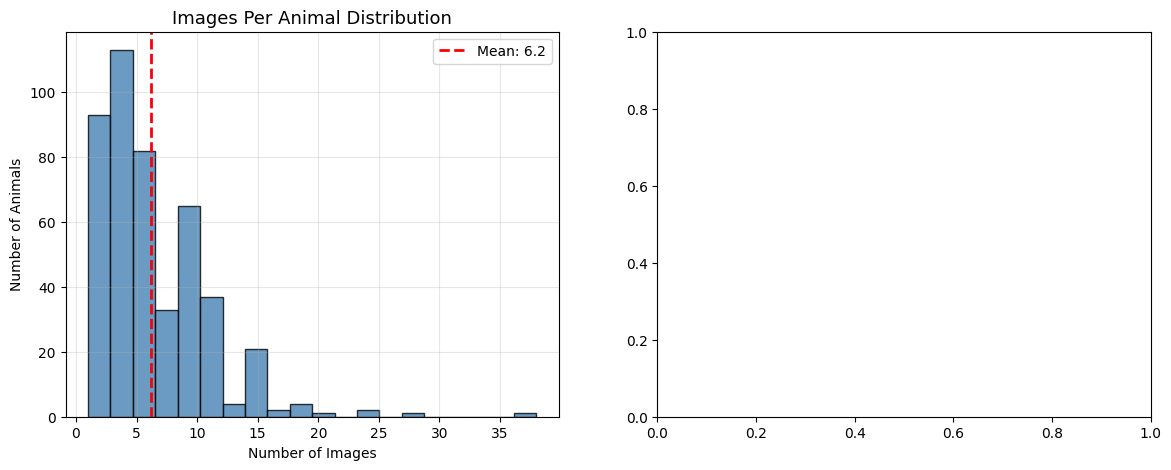

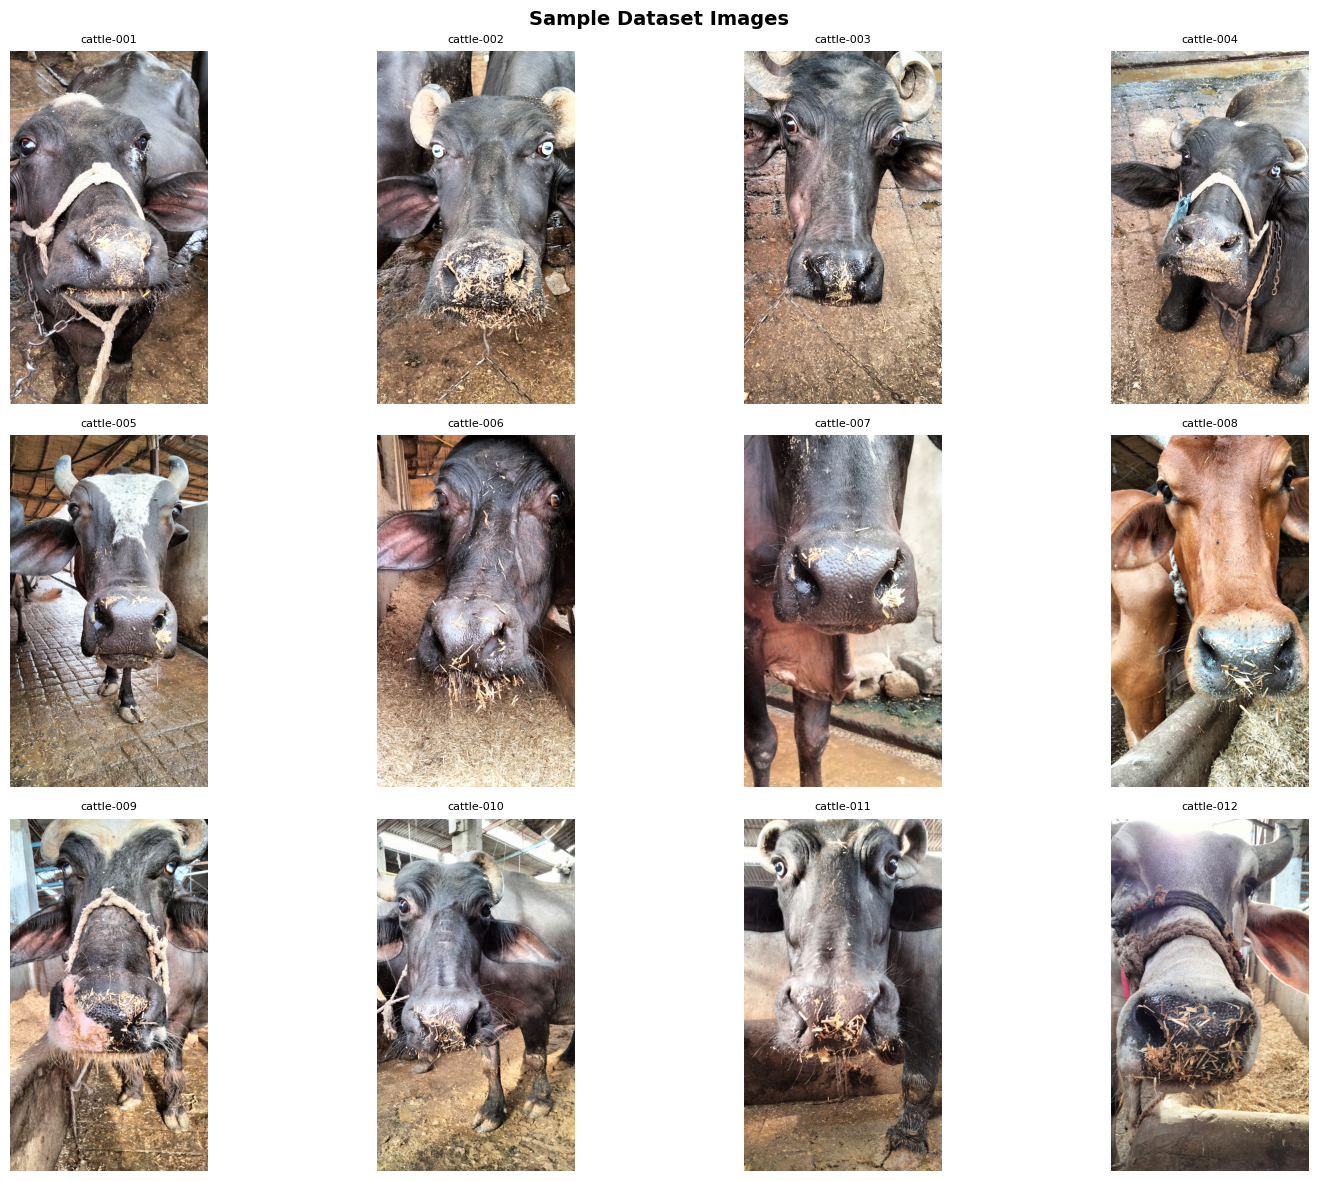


First 10 animal folders:
  📁 cattle-001                     → 9 images
  📁 cattle-002                     → 5 images
  📁 cattle-003                     → 3 images
  📁 cattle-004                     → 5 images
  📁 cattle-005                     → 3 images
  📁 cattle-006                     → 4 images
  📁 cattle-007                     → 3 images
  📁 cattle-008                     → 3 images
  📁 cattle-009                     → 6 images
  📁 cattle-010                     → 7 images


In [ ]:
# ============================================================
# CELL 6: FIND CORRECT DATASET PATH + SHOW STATISTICS
# ============================================================

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def find_dataset_root(base_path):
    """Find the folder containing animal subfolders with images"""
    best_path  = None
    best_count = 0

    for dirpath, dirnames, filenames in os.walk(base_path):
        count = 0
        for subdir in dirnames:
            sub_path = os.path.join(dirpath, subdir)
            try:
                imgs = [f for f in os.listdir(sub_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
                if imgs:
                    count += 1
            except:
                pass
        if count > best_count:
            best_count = count
            best_path  = dirpath

    return best_path, best_count


# Find path
DATASET_PATH, num_animals = find_dataset_root(COLAB_DATA)

print(f"✅ Dataset found!")
print(f"   Path:    {DATASET_PATH}")
print(f"   Animals: {num_animals}")

# Collect statistics
animal_folders = sorted([
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
])

total_images      = 0
images_per_animal = []
sample_images     = []
image_sizes       = []

for animal in animal_folders:
    path = os.path.join(DATASET_PATH, animal)
    imgs = [f for f in os.listdir(path)
            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
    count = len(imgs)
    total_images += count
    images_per_animal.append(count)

    if imgs:
        first_img_path = os.path.join(path, imgs[0])
        if len(sample_images) < 12:
            sample_images.append((first_img_path, animal))
        try:
            img = Image.open(first_img_path)
            image_sizes.append(img.size)
        except:
            pass

print(f"\nDATASET STATISTICS:")
print(f"  Total Animals:     {len(animal_folders)}")
print(f"  Total Images:      {total_images}")
print(f"  Avg Images/Animal: {np.mean(images_per_animal):.1f}")
print(f"  Min Images:        {min(images_per_animal)}")
print(f"  Max Images:        {max(images_per_animal)}")
print(f"  Median Images:     {np.median(images_per_animal):.0f}")

if image_sizes:
    widths  = [s[0] for s in image_sizes]
    heights = [s[1] for s in image_sizes]
    print(f"\nIMAGE DIMENSIONS:")
    print(f"  Width  → Min:{min(widths)} Max:{max(widths)} Avg:{np.mean(widths):.0f}")
    print(f"  Height → Min:{min(heights)} Max:{max(heights)} Avg:{np.mean(heights):.0f}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(images_per_animal, bins=20,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(np.mean(images_per_animal), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(images_per_animal):.1f}')
axes[0].set_title('Images Per Animal Distribution', fontsize=13)
axes[0].set_xlabel('Number of Images')
axes[0].set_ylabel('Number of Animals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sample images grid
if sample_images:
    cols = 4
    rows = 3
    fig2, axes2 = plt.subplots(rows, cols, figsize=(16, 12))
    for idx, (img_path, name) in enumerate(sample_images[:rows*cols]):
        r, c = idx // cols, idx % cols
        try:
            img = Image.open(img_path).convert('RGB')
            axes2[r][c].imshow(img)
            axes2[r][c].set_title(name[:15], fontsize=8)
        except:
            axes2[r][c].text(0.5, 0.5, 'Error', ha='center')
        axes2[r][c].axis('off')
    plt.suptitle('Sample Dataset Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'sample_images.png'), dpi=100)
    plt.show()

print(f"\nFirst 10 animal folders:")
for folder in animal_folders[:10]:
    p = os.path.join(DATASET_PATH, folder)
    n = len([f for f in os.listdir(p)
             if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
    print(f"  📁 {folder:<30} → {n} images")

In [ ]:
# ============================================================
# CELL 7: SCAN IMAGE QUALITY
# Check all images for issues before training
# ============================================================

import cv2
import os

def check_image_quality(image_path):
    """Check single image quality"""
    try:
        img = cv2.imread(str(image_path))
        if img is None:
            return False, "Cannot read"

        h, w = img.shape[:2]
        if h < 50 or w < 50:
            return False, f"Too small: {w}x{h}"

        gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur  = cv2.Laplacian(gray, cv2.CV_64F).var()
        if blur < 10:
            return False, f"Too blurry: {blur:.1f}"

        return True, f"OK: {w}x{h} blur={blur:.0f}"
    except Exception as e:
        return False, str(e)


def scan_dataset(dataset_path):
    """Scan all images and report quality"""
    print("Scanning image quality...")
    print("=" * 50)

    good_count = 0
    bad_count  = 0
    bad_files  = []

    folders = [f for f in os.listdir(dataset_path)
               if os.path.isdir(os.path.join(dataset_path, f))]

    for animal in folders:
        animal_path = os.path.join(dataset_path, animal)
        imgs = [f for f in os.listdir(animal_path)
                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]

        for img_file in imgs:
            img_path = os.path.join(animal_path, img_file)
            is_good, reason = check_image_quality(img_path)
            if is_good:
                good_count += 1
            else:
                bad_count += 1
                bad_files.append((img_path, reason))

    print(f"Total scanned: {good_count + bad_count}")
    print(f"Good Images:   {good_count}")
    print(f"Bad Images:    {bad_count}")

    if bad_files:
        print(f"\nFirst 10 bad files:")
        for path, reason in bad_files[:10]:
            print(f"  {os.path.basename(path)}: {reason}")
    else:
        print("\n✅ All images passed quality check!")

    return good_count, bad_count


good_count, bad_count = scan_dataset(DATASET_PATH)

Scanning image quality...
Total scanned: 2847
Good Images:   2764
Bad Images:    83

First 10 bad files:
  IMG_0219-00.jpg: Too blurry: 6.3
  IMG_0553-01.jpg: Too blurry: 9.5
  IMG20230727070048-02.jpg: Too blurry: 9.2
  IMG_0985-02.jpg: Too blurry: 8.1
  IMG_0990-00.jpg: Too blurry: 5.5
  IMG_0750-02.jpg: Too blurry: 4.5
  IMG_0748-01.jpg: Too blurry: 4.0
  IMG_0711-02.jpg: Too blurry: 7.3
  IMG_0700-01.jpg: Too blurry: 6.2
  IMG_0017-01.jpg: Too blurry: 8.1


In [ ]:
# ============================================================
# CELL 8: GLOBAL CONFIGURATION
# All settings in one place
# Optimized for FREE Colab GPU limits
# ============================================================

import torch

# ── DEVICE ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── OPTIMIZED CONFIG FOR FREE COLAB ──
CONFIG = {

    # Image settings
    'image_size':    128,   # 128x128 → 4x less memory than 224x224
    'embedding_size': 128,  # Lighter than 256

    # Training settings
    'batch_size':    16,    # Half of 32 → less GPU memory
    'epochs':        30,    # Enough with pretrained backbone
    'learning_rate': 0.0003,
    'weight_decay':  1e-4,
    'margin':        1.0,   # Contrastive loss margin

    # Dataset settings
    'pairs_per_animal':  8,  # Pairs generated per animal
    'same_pair_ratio':   0.5,
    'train_ratio':       0.8,
    'val_ratio':         0.1,
    'test_ratio':        0.1,

    # Training optimization
    'use_fp16':             True,   # Mixed precision → 40% less memory
    'num_workers':          2,
    'early_stop_patience':  10,
    'save_every_epochs':    5,

    # Paths
    'save_dir':      SAVE_DIR,
    'dataset_path':  DATASET_PATH,
}

print("CONFIGURATION:")
print("=" * 50)
print(f"Device:           {device}")
for key, val in CONFIG.items():
    if key not in ['save_dir', 'dataset_path']:
        print(f"  {key:<25}: {val}")

print(f"\nGPU MEMORY ESTIMATE:")
print(f"  Image size {CONFIG['image_size']}x{CONFIG['image_size']}, "
      f"Batch {CONFIG['batch_size']}, FP16={CONFIG['use_fp16']}")
print(f"  Estimated GPU usage: ~3-5 GB")
print(f"  Free Colab limit:    ~15 GB")
print(f"  Status: ✅ Well within limit")

CONFIGURATION:
Device:           cpu
  image_size               : 128
  embedding_size           : 128
  batch_size               : 16
  epochs                   : 30
  learning_rate            : 0.0003
  weight_decay             : 0.0001
  margin                   : 1.0
  pairs_per_animal         : 8
  same_pair_ratio          : 0.5
  train_ratio              : 0.8
  val_ratio                : 0.1
  test_ratio               : 0.1
  use_fp16                 : True
  num_workers              : 2
  early_stop_patience      : 10
  save_every_epochs        : 5

GPU MEMORY ESTIMATE:
  Image size 128x128, Batch 16, FP16=True
  Estimated GPU usage: ~3-5 GB
  Free Colab limit:    ~15 GB
  Status: ✅ Well within limit


In [ ]:
# ============================================================
# CELL 9: SPLIT DATASET INTO TRAIN / VAL / TEST
# Animals are split (not images)
# Same animal never appears in multiple splits
# ============================================================

import random
import os

# Get animals with at least 2 images (need pairs)
valid_animals     = []
skipped_animals   = []

for animal in animal_folders:
    path = os.path.join(DATASET_PATH, animal)
    imgs = [f for f in os.listdir(path)
            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
    if len(imgs) >= 2:
        valid_animals.append(animal)
    else:
        skipped_animals.append(animal)

print(f"Animals with 2+ images (usable): {len(valid_animals)}")
print(f"Animals with <2 images (skipped): {len(skipped_animals)}")

# Reproducible shuffle with fixed seed
random.seed(42)
random.shuffle(valid_animals)

# Split
total     = len(valid_animals)
train_end = int(total * CONFIG['train_ratio'])
val_end   = int(total * (CONFIG['train_ratio'] + CONFIG['val_ratio']))

train_animals = valid_animals[:train_end]
val_animals   = valid_animals[train_end:val_end]
test_animals  = valid_animals[val_end:]

print(f"\nDataset Split (seed=42, reproducible):")
print(f"  Total usable: {total} animals")
print(f"  Train:        {len(train_animals)} ({CONFIG['train_ratio']*100:.0f}%)")
print(f"  Validation:   {len(val_animals)} ({CONFIG['val_ratio']*100:.0f}%)")
print(f"  Test:         {len(test_animals)} ({CONFIG['test_ratio']*100:.0f}%)")

# Verify no overlap
train_set = set(train_animals)
val_set   = set(val_animals)
test_set  = set(test_animals)

assert len(train_set & val_set)  == 0, "Train/Val overlap!"
assert len(train_set & test_set) == 0, "Train/Test overlap!"
assert len(val_set & test_set)   == 0, "Val/Test overlap!"
print("\n✅ No overlap between splits — correct!")

Animals with 2+ images (usable): 405
Animals with <2 images (skipped): 54

Dataset Split (seed=42, reproducible):
  Total usable: 405 animals
  Train:        324 (80%)
  Validation:   40 (10%)
  Test:         41 (10%)

✅ No overlap between splits — correct!


In [ ]:
# ============================================================
# CELL 10: DATASET CLASS + TRANSFORMS + DATALOADERS
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import random
import os


class SiameseMuzzleDataset(Dataset):
    """
    Generates pairs of muzzle images for Siamese training

    Returns: (image1, image2, label)
      label = 1.0  →  Same animal
      label = 0.0  →  Different animal
    """

    def __init__(self, dataset_path, animal_list,
                 transform, pairs_per_animal=8, same_ratio=0.5):

        self.dataset_path = dataset_path
        self.transform    = transform
        self.same_ratio   = same_ratio

        # Build image index
        self.animal_images = {}
        for animal in animal_list:
            animal_path = os.path.join(dataset_path, animal)
            if not os.path.isdir(animal_path):
                continue
            images = [
                os.path.join(animal_path, f)
                for f in os.listdir(animal_path)
                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))
            ]
            if len(images) >= 2:
                self.animal_images[animal] = images

        self.animal_ids = list(self.animal_images.keys())
        self.size       = len(self.animal_ids) * pairs_per_animal

    def __len__(self):
        return self.size

    def safe_load(self, path):
        """Load image with error handling"""
        img_size = CONFIG['image_size']
        try:
            img = Image.open(path).convert('RGB')
            return self.transform(img)
        except:
            return torch.zeros(3, img_size, img_size)

    def __getitem__(self, idx):
        is_same = random.random() < self.same_ratio

        if is_same:
            # Same animal — pick 2 different photos
            animal    = random.choice(self.animal_ids)
            p1, p2    = random.sample(self.animal_images[animal], 2)
            label     = 1.0
        else:
            # Different animals
            a1, a2    = random.sample(self.animal_ids, 2)
            p1        = random.choice(self.animal_images[a1])
            p2        = random.choice(self.animal_images[a2])
            label     = 0.0

        img1 = self.safe_load(p1)
        img2 = self.safe_load(p2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)


# ── TRANSFORMS ──
IMG_SIZE = CONFIG['image_size']

# Training: with augmentation for robustness
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.1, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test: no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ── CREATE DATASETS ──
print("Creating datasets...")

train_dataset = SiameseMuzzleDataset(
    DATASET_PATH, train_animals, train_transform,
    pairs_per_animal=CONFIG['pairs_per_animal'],
    same_ratio=CONFIG['same_pair_ratio']
)

val_dataset = SiameseMuzzleDataset(
    DATASET_PATH, val_animals, val_transform,
    pairs_per_animal=CONFIG['pairs_per_animal'],
    same_ratio=CONFIG['same_pair_ratio']
)

test_dataset = SiameseMuzzleDataset(
    DATASET_PATH, test_animals, val_transform,
    pairs_per_animal=CONFIG['pairs_per_animal'],
    same_ratio=CONFIG['same_pair_ratio']
)

# ── CREATE DATALOADERS ──
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"\nDatasets created:")
print(f"  Train: {len(train_dataset):,} pairs → {len(train_loader)} batches")
print(f"  Val:   {len(val_dataset):,} pairs → {len(val_loader)} batches")
print(f"  Test:  {len(test_dataset):,} pairs → {len(test_loader)} batches")

# Quick test
i1, i2, lb = next(iter(train_loader))
print(f"\n✅ Batch test passed!")
print(f"  Image shape: {i1.shape}")
print(f"  Labels: {lb[:6].tolist()}")

Creating datasets...

Datasets created:
  Train: 2,592 pairs → 162 batches
  Val:   320 pairs → 20 batches
  Test:  328 pairs → 21 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ Batch test passed!
  Image shape: torch.Size([16, 3, 128, 128])
  Labels: [0.0, 1.0, 1.0, 1.0, 1.0, 0.0]


In [ ]:
# ============================================================
# CELL 11: SIAMESE NETWORK WITH MOBILENETV3
#
# WHY MOBILENETV3 NOT RESNET50:
#   ResNet50   → 25M params, ~12GB GPU, slow
#   MobileNetV3 → 2.5M params, ~3GB GPU, fast
#   For free Colab → MobileNetV3 is the right choice
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models


class LightMuzzleEncoder(nn.Module):
    """
    Converts a muzzle image into a 128-dim embedding vector

    Embedding = unique numerical fingerprint of the muzzle
    Same animal → similar embeddings (small distance)
    Different animal → different embeddings (large distance)
    """

    def __init__(self, embedding_size=128):
        super(LightMuzzleEncoder, self).__init__()

        # Pretrained MobileNetV3-Small backbone
        mobilenet      = models.mobilenet_v3_small(pretrained=True)
        self.backbone  = mobilenet.features  # Feature extractor
        self.pool      = nn.AdaptiveAvgPool2d(1)  # Global average pool

        # Freeze first 8 layers (detect basic features: edges, colors)
        # Train last layers (learn muzzle-specific patterns)
        for i, layer in enumerate(self.backbone):
            requires_grad = (i >= 8)
            for param in layer.parameters():
                param.requires_grad = requires_grad

        # Projection head: 576 features → embedding_size
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(576, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, embedding_size),
            nn.BatchNorm1d(embedding_size)
        )

    def forward(self, x):
        features  = self.backbone(x)  # Extract visual features
        pooled    = self.pool(features)  # Pool to fixed size
        embedding = self.head(pooled)    # Project to embedding
        # L2 normalize → unit sphere → cosine sim = dot product
        embedding = nn.functional.normalize(embedding, p=2, dim=1)
        return embedding


class SiameseNetwork(nn.Module):
    """
    Siamese Network wrapper

    Both images use SAME encoder (shared weights)
    This ensures consistent embedding space
    """

    def __init__(self, embedding_size=128):
        super(SiameseNetwork, self).__init__()
        self.encoder = LightMuzzleEncoder(embedding_size)

    def forward(self, img1, img2):
        """Process image pair → return both embeddings"""
        emb1 = self.encoder(img1)
        emb2 = self.encoder(img2)
        return emb1, emb2

    def get_embedding(self, img):
        """Get single image embedding (for registration/matching)"""
        return self.encoder(img)


# ── CREATE MODEL ──
model = SiameseNetwork(
    embedding_size=CONFIG['embedding_size']
).to(device)

# Parameter count
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters()
                  if p.requires_grad)
frozen_p    = total_p - trainable_p

print("MODEL CREATED:")
print(f"  Architecture:  Siamese Network (MobileNetV3-Small)")
print(f"  Device:        {device}")
print(f"  Total Params:  {total_p:,}")
print(f"  Trainable:     {trainable_p:,}")
print(f"  Frozen:        {frozen_p:,}")
print(f"  Model Size:    ~{total_p * 4 / 1e6:.1f} MB")
print(f"  Embedding:     {CONFIG['embedding_size']} dimensions")

# Test forward pass
with torch.no_grad():
    test_img = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    e1, e2   = model(test_img, test_img)
    print(f"\n✅ Forward pass test:")
    print(f"  Input shape:     {test_img.shape}")
    print(f"  Embedding shape: {e1.shape}")
    print(f"  Embedding norm:  {e1.norm(dim=1).mean():.4f} (should be ~1.0)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 282MB/s]


MODEL CREATED:
  Architecture:  Siamese Network (MobileNetV3-Small)
  Device:        cpu
  Total Params:  1,108,384
  Trainable:     947,664
  Frozen:        160,720
  Model Size:    ~4.4 MB
  Embedding:     128 dimensions

✅ Forward pass test:
  Input shape:     torch.Size([2, 3, 128, 128])
  Embedding shape: torch.Size([2, 128])
  Embedding norm:  1.0000 (should be ~1.0)


In [ ]:
# ============================================================
# CELL 12: LOSS + OPTIMIZER + SCHEDULER
# ============================================================

import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau


class ContrastiveLoss(nn.Module):
    """
    Contrastive Loss for Siamese Networks

    Same pair  (label=1): Loss = distance²        → minimize distance
    Diff pair  (label=0): Loss = max(margin-dist,0)² → push apart

    margin = minimum separation we want between different animals
    """

    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        # Euclidean distance between embeddings
        distance = nn.functional.pairwise_distance(emb1, emb2)

        # Same animal loss: minimize distance
        same_loss = label * distance.pow(2)

        # Different animal loss: maximize distance beyond margin
        diff_loss = (1 - label) * torch.clamp(
            self.margin - distance, min=0.0
        ).pow(2)

        loss = (same_loss + diff_loss).mean() / 2.0
        return loss, distance.detach()


# ── LOSS ──
criterion = ContrastiveLoss(margin=CONFIG['margin'])

# ── OPTIMIZER ──
# Different LRs: slow for pretrained layers, fast for new layers
optimizer = optim.Adam([
    {
        'params': model.encoder.backbone.parameters(),
        'lr':     CONFIG['learning_rate'] * 0.1  # 10x slower
    },
    {
        'params': model.encoder.head.parameters(),
        'lr':     CONFIG['learning_rate']         # Normal speed
    }
], weight_decay=CONFIG['weight_decay'])

# ── SCHEDULER ──
# Reduce LR when validation loss stops improving
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=4,
    factor=0.5,
    min_lr=1e-8
)

# ── MIXED PRECISION SCALER ──
# FP16 = half precision → ~40% less GPU memory, ~2x faster
scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_fp16'])

print("Loss:      ContrastiveLoss (margin=1.0)")
print("Optimizer: Adam")
print(f"  Backbone LR:  {CONFIG['learning_rate'] * 0.1}")
print(f"  Head LR:      {CONFIG['learning_rate']}")
print(f"Mixed Precision (FP16): {CONFIG['use_fp16']}")
print("Scheduler: ReduceLROnPlateau (patience=4, factor=0.5)")

Loss:      ContrastiveLoss (margin=1.0)
Optimizer: Adam
  Backbone LR:  2.9999999999999997e-05
  Head LR:      0.0003
Mixed Precision (FP16): True
Scheduler: ReduceLROnPlateau (patience=4, factor=0.5)


/tmp/ipykernel_1111/4274333990.py:68: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_fp16'])
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


In [ ]:
# ============================================================
# CELL 13: TRAINING AND VALIDATION FUNCTIONS
# ============================================================

from tqdm import tqdm
import torch


def train_one_epoch(model, loader, optimizer,
                    criterion, scaler, device, use_fp16):
    """Train for one complete epoch"""
    model.train()
    total_loss = 0.0
    total_acc  = 0.0
    n_batches  = 0

    pbar = tqdm(loader, desc="  Training", leave=False)

    for img1, img2, labels in pbar:
        img1   = img1.to(device, non_blocking=True)
        img2   = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward pass with mixed precision
        with torch.cuda.amp.autocast(enabled=use_fp16):
            emb1, emb2          = model(img1, img2)
            loss, distances     = criterion(emb1, emb2, labels)

        # Backward pass with mixed precision
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # Accuracy: distance < 0.5 → predict same animal
        preds = (distances < 0.5).float().cpu()
        acc   = (preds == labels.cpu()).float().mean().item()

        total_loss += loss.item()
        total_acc  += acc
        n_batches  += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc':  f'{acc:.4f}'
        })

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, use_fp16):
    """Validate — no gradient updates"""
    model.eval()
    total_loss   = 0.0
    total_acc    = 0.0
    n_batches    = 0
    all_distances = []
    all_labels    = []

    pbar = tqdm(loader, desc="  Validating", leave=False)

    for img1, img2, labels in pbar:
        img1   = img1.to(device, non_blocking=True)
        img2   = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_fp16):
            emb1, emb2      = model(img1, img2)
            loss, distances = criterion(emb1, emb2, labels)

        preds = (distances < 0.5).float().cpu()
        acc   = (preds == labels.cpu()).float().mean().item()

        total_loss   += loss.item()
        total_acc    += acc
        n_batches    += 1

        all_distances.extend(distances.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    return (total_loss / n_batches,
            total_acc / n_batches,
            all_distances,
            all_labels)


print("✅ Training functions ready!")

✅ Training functions ready!


In [ ]:
# ============================================================
# CELL 14: MAIN TRAINING LOOP
# ~15-25 minutes on free T4 GPU
# Model saved to Google Drive automatically
# ============================================================

import time
import json
import os

# Training history
history = {
    'train_loss':  [],
    'train_acc':   [],
    'val_loss':    [],
    'val_acc':     [],
    'lr':          [],
    'epoch_time':  []
}

best_val_loss    = float('inf')
best_epoch       = 0
patience_counter = 0

print("=" * 65)
print("  LIVESTOCK GUARDIAN — MUZZLE RECOGNITION TRAINING")
print("=" * 65)
print(f"  Model:       Siamese Network (MobileNetV3-Small)")
print(f"  Image Size:  {CONFIG['image_size']}x{CONFIG['image_size']} px")
print(f"  Batch Size:  {CONFIG['batch_size']}")
print(f"  Epochs:      {CONFIG['epochs']}")
print(f"  Embedding:   {CONFIG['embedding_size']} dim")
print(f"  FP16:        {CONFIG['use_fp16']}")
print(f"  Device:      {device}")
print(f"  Save to:     {SAVE_DIR}")
print("=" * 65)

training_start = time.time()

for epoch in range(1, CONFIG['epochs'] + 1):
    epoch_start = time.time()

    # ── TRAIN ──
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer,
        criterion, scaler, device, CONFIG['use_fp16']
    )

    # ── VALIDATE ──
    val_loss, val_acc, val_dist, val_lbl = validate_one_epoch(
        model, val_loader, criterion,
        device, CONFIG['use_fp16']
    )

    # ── SCHEDULER UPDATE ──
    scheduler.step(val_loss)
    current_lr  = optimizer.param_groups[-1]['lr']
    epoch_time  = time.time() - epoch_start

    # ── RECORD ──
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    history['epoch_time'].append(epoch_time)

    # ── PRINT ──
    print(f"Epoch {epoch:2d}/{CONFIG['epochs']} │ "
          f"Train Loss:{train_loss:.4f} Acc:{train_acc:.4f} │ "
          f"Val Loss:{val_loss:.4f} Acc:{val_acc:.4f} │ "
          f"LR:{current_lr:.1e} │ {epoch_time:.0f}s")

    # ── SAVE BEST MODEL ──
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch
        patience_counter = 0

        torch.save({
            'epoch':              epoch,
            'model_state_dict':   model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':           val_loss,
            'val_acc':            val_acc,
            'train_loss':         train_loss,
            'train_acc':          train_acc,
            'config':             CONFIG,
            'history':            history
        }, os.path.join(SAVE_DIR, 'best_model.pth'))

        print(f"  ✅ Best model saved! "
              f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['early_stop_patience']:
            print(f"\n⏹ Early stopping triggered at epoch {epoch}")
            print(f"  Best epoch: {best_epoch}")
            break

    # ── PERIODIC CHECKPOINT ──
    if epoch % CONFIG['save_every_epochs'] == 0:
        ckpt_path = os.path.join(
            SAVE_DIR, f'checkpoint_epoch_{epoch}.pth'
        )
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'config':           CONFIG,
            'history':          history
        }, ckpt_path)
        print(f"  💾 Checkpoint saved: epoch {epoch}")

    # Clear GPU cache each epoch
    torch.cuda.empty_cache()

# ── TRAINING COMPLETE ──
total_time = time.time() - training_start
print(f"\n{'='*65}")
print(f"TRAINING COMPLETE!")
print(f"  Total Time:     {total_time/60:.1f} minutes")
print(f"  Best Epoch:     {best_epoch}")
print(f"  Best Val Loss:  {best_val_loss:.4f}")
print(f"{'='*65}")

  LIVESTOCK GUARDIAN — MUZZLE RECOGNITION TRAINING
  Model:       Siamese Network (MobileNetV3-Small)
  Image Size:  128x128 px
  Batch Size:  16
  Epochs:      30
  Embedding:   128 dim
  FP16:        True
  Device:      cpu
  Save to:     /content/drive/MyDrive/livestock_guardian/models


  Training:   0%|          | 0/162 [00:00<?, ?it/s]/tmp/ipykernel_1111/821750575.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_fp16):
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
  Validating:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_1111/821750575.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_fp16):


Epoch  1/30 │ Train Loss:0.3086 Acc:0.5181 │ Val Loss:0.1665 Acc:0.6531 │ LR:3.0e-04 │ 647s
  ✅ Best model saved! Val Loss: 0.1665 | Acc: 0.6531


Epoch  2/30 │ Train Loss:0.1999 Acc:0.5953 │ Val Loss:0.1317 Acc:0.7344 │ LR:3.0e-04 │ 704s
  ✅ Best model saved! Val Loss: 0.1317 | Acc: 0.7344


Epoch  3/30 │ Train Loss:0.1486 Acc:0.6698 │ Val Loss:0.0874 Acc:0.8063 │ LR:3.0e-04 │ 720s
  ✅ Best model saved! Val Loss: 0.0874 | Acc: 0.8063


...

Epoch 26/30 │ Train Loss:0.0584 Acc:0.8546 │ Val Loss:0.0495 Acc:0.8875 │ LR:7.5e-05 │ 715s


Epoch 27/30 │ Train Loss:0.0551 Acc:0.8607 │ Val Loss:0.0452 Acc:0.8938 │ LR:7.5e-05 │ 720s
  ✅ Best model saved! Val Loss: 0.0452 | Acc: 0.8938


Epoch 28/30 │ Train Loss:0.0546 Acc:0.8669 │ Val Loss:0.0438 Acc:0.8875 │ LR:7.5e-05 │ 718s
  ✅ Best model saved! Val Loss: 0.0438 | Acc: 0.8875


Epoch 29/30 │ Train Loss:0.0542 Acc:0.8657 │ Val Loss:0.0582 Acc:0.8531 │ LR:7.5e-05 │ 712s


Epoch 30/30 │ Train Loss:0.0581 Acc:0.8526 │ Val Loss:0.0501 Acc:0.8656 │ LR:7.5e-05 │ 713s
  💾 Checkpoint saved: epoch 30

TRAINING COMPLETE!
  Total Time:     356.5 minutes
  Best Epoch:     28
  Best Val Loss:  0.0438


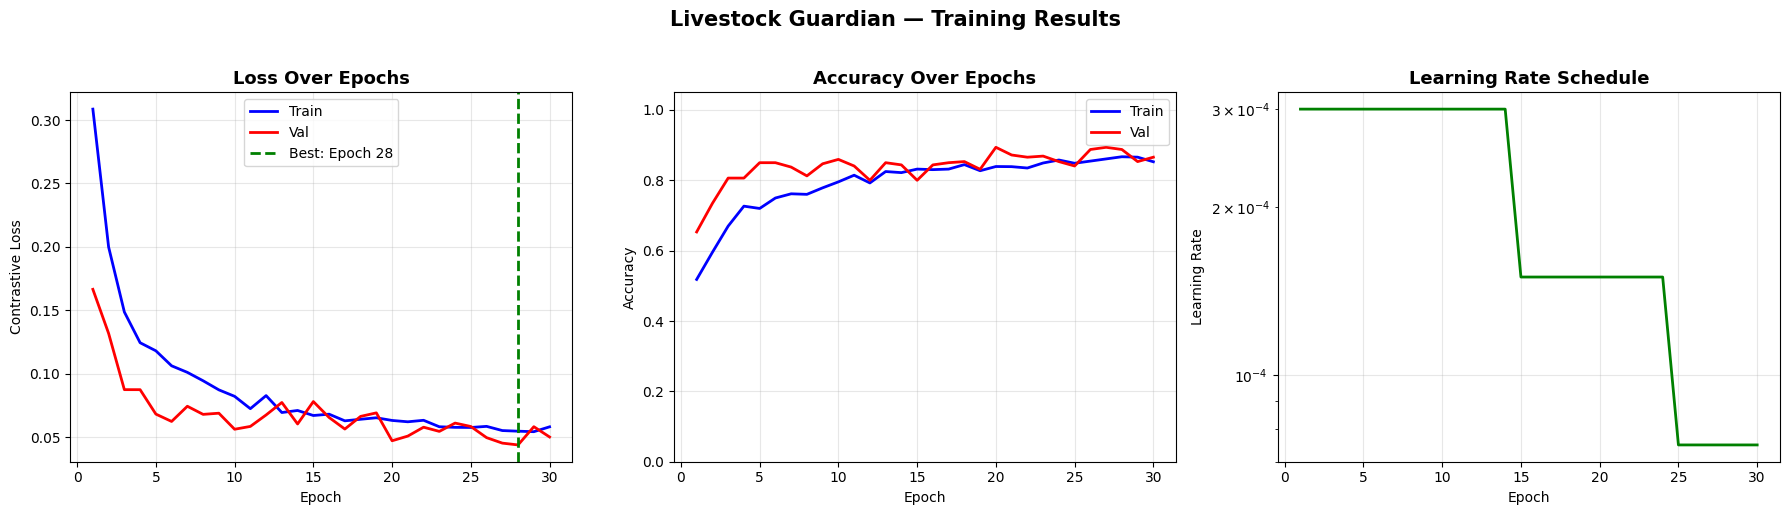

✅ Training plot saved: /content/drive/MyDrive/livestock_guardian/models/training_plot.png


In [ ]:
# ============================================================
# CELL 15: VISUALIZE TRAINING RESULTS
# ============================================================

import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'],
             'b-', linewidth=2, label='Train')
axes[0].plot(epochs_range, history['val_loss'],
             'r-', linewidth=2, label='Val')
axes[0].axvline(best_epoch, color='g', linestyle='--',
                linewidth=2, label=f'Best: Epoch {best_epoch}')
axes[0].set_title('Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Contrastive Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'],
             'b-', linewidth=2, label='Train')
axes[1].plot(epochs_range, history['val_acc'],
             'r-', linewidth=2, label='Val')
axes[1].set_title('Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(epochs_range, history['lr'],
             'g-', linewidth=2)
axes[2].set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'Livestock Guardian — Training Results',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()

plot_path = os.path.join(SAVE_DIR, 'training_plot.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Training plot saved: {plot_path}")

✅ Best model loaded from epoch 28


Computing distances:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_1111/4173003581.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_fp16']):
Computing distances: 100%|██████████| 20/20 [01:21<00:00,  4.08s/it]



OPTIMAL THRESHOLD RESULTS:
  Best Threshold: 0.570
  Accuracy:       0.9094 (90.94%)
  Precision:      0.8944
  Recall:         0.9415
  F1 Score:       0.9174


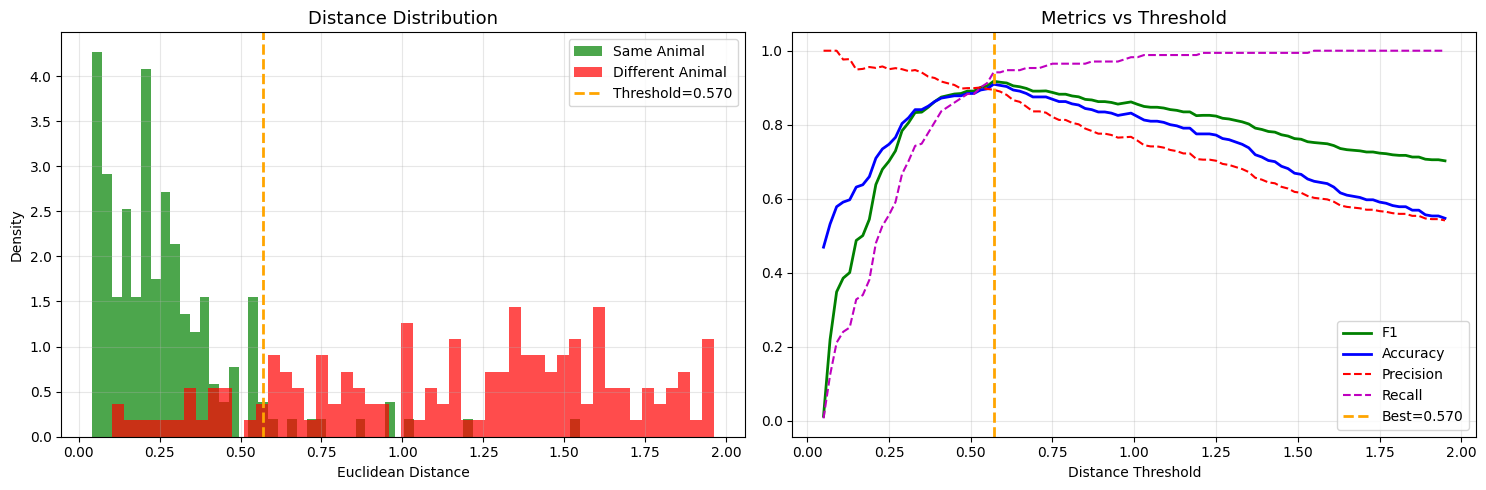


Same Animal   → Mean:0.2726 Std:0.2208
Diff Animal   → Mean:1.1710 Std:0.4863
Separation:   → 0.8984


In [ ]:
# ============================================================
# CELL 16: FIND OPTIMAL MATCHING THRESHOLD
#
# Threshold = distance below which we say "same animal"
# We test many thresholds and pick the one with best F1
# ============================================================

import numpy as np
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn

# Load best model
checkpoint = torch.load(
    os.path.join(SAVE_DIR, 'best_model.pth'),
    map_location=device
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Best model loaded from epoch {checkpoint['epoch']}")

# Collect all distances from validation set
all_distances = []
all_labels    = []

with torch.no_grad():
    for img1, img2, labels in tqdm(val_loader, desc="Computing distances"):
        img1, img2 = img1.to(device), img2.to(device)

        with torch.cuda.amp.autocast(enabled=CONFIG['use_fp16']):
            emb1, emb2 = model(img1, img2)

        dist = nn.functional.pairwise_distance(emb1, emb2)
        all_distances.extend(dist.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

all_distances = np.array(all_distances)
all_labels    = np.array(all_labels)

# Test thresholds from 0.05 to 2.0
thresholds  = np.arange(0.05, 2.0, 0.02)
best_f1     = 0.0
best_threshold = 0.5
results     = []

for t in thresholds:
    preds = (all_distances < t).astype(int)
    if len(np.unique(preds)) < 2:
        continue
    acc  = accuracy_score(all_labels, preds)
    prec = precision_score(all_labels, preds, zero_division=0)
    rec  = recall_score(all_labels, preds, zero_division=0)
    f1   = f1_score(all_labels, preds, zero_division=0)
    results.append({
        'threshold': float(t),
        'accuracy':  float(acc),
        'precision': float(prec),
        'recall':    float(rec),
        'f1':        float(f1)
    })
    if f1 > best_f1:
        best_f1        = f1
        best_threshold = float(t)

# Final metrics at best threshold
final_preds = (all_distances < best_threshold).astype(int)
final_acc   = accuracy_score(all_labels, final_preds)
final_f1    = f1_score(all_labels, final_preds, zero_division=0)
final_prec  = precision_score(all_labels, final_preds, zero_division=0)
final_rec   = recall_score(all_labels, final_preds, zero_division=0)

print(f"\nOPTIMAL THRESHOLD RESULTS:")
print(f"  Best Threshold: {best_threshold:.3f}")
print(f"  Accuracy:       {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"  Precision:      {final_prec:.4f}")
print(f"  Recall:         {final_rec:.4f}")
print(f"  F1 Score:       {final_f1:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distance distribution
same_dist = all_distances[all_labels == 1]
diff_dist = all_distances[all_labels == 0]

axes[0].hist(same_dist, bins=50, alpha=0.7,
             color='green', label='Same Animal', density=True)
axes[0].hist(diff_dist, bins=50, alpha=0.7,
             color='red', label='Different Animal', density=True)
axes[0].axvline(best_threshold, color='orange', linestyle='--',
                linewidth=2, label=f'Threshold={best_threshold:.3f}')
axes[0].set_title('Distance Distribution', fontsize=13)
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metrics vs threshold
t_vals   = [r['threshold'] for r in results]
axes[1].plot(t_vals, [r['f1'] for r in results],
             'g-', linewidth=2, label='F1')
axes[1].plot(t_vals, [r['accuracy'] for r in results],
             'b-', linewidth=2, label='Accuracy')
axes[1].plot(t_vals, [r['precision'] for r in results],
             'r--', linewidth=1.5, label='Precision')
axes[1].plot(t_vals, [r['recall'] for r in results],
             'm--', linewidth=1.5, label='Recall')
axes[1].axvline(best_threshold, color='orange', linestyle='--',
                linewidth=2, label=f'Best={best_threshold:.3f}')
axes[1].set_title('Metrics vs Threshold', fontsize=13)
axes[1].set_xlabel('Distance Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
thresh_plot = os.path.join(SAVE_DIR, 'threshold_analysis.png')
plt.savefig(thresh_plot, dpi=150)
plt.show()

print(f"\nSame Animal   → Mean:{same_dist.mean():.4f} Std:{same_dist.std():.4f}")
print(f"Diff Animal   → Mean:{diff_dist.mean():.4f} Std:{diff_dist.std():.4f}")
print(f"Separation:   → {diff_dist.mean() - same_dist.mean():.4f}")

Testing:   0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_1111/2059441924.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_fp16']):
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Testing: 100%|██████████| 21/21 [01:26<00:00,  4.13s/it]


FINAL TEST SET RESULTS
                  precision    recall  f1-score   support

Different Animal       0.97      0.79      0.87       175
     Same Animal       0.80      0.97      0.88       153

        accuracy                           0.88       328
       macro avg       0.89      0.88      0.87       328
    weighted avg       0.89      0.88      0.87       328

Test Accuracy:  0.8750 (87.50%)
Test F1 Score:  0.8791


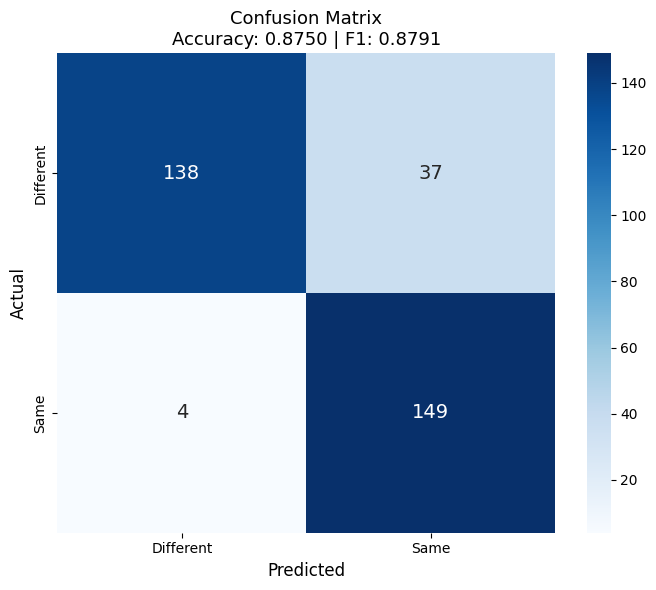

✅ Confusion matrix saved: /content/drive/MyDrive/livestock_guardian/models/confusion_matrix.png


In [ ]:
# ============================================================
# CELL 17: FINAL TEST SET EVALUATION
# Test set was never seen during training or threshold tuning
# This gives honest performance estimate
# ============================================================

import numpy as np
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score, f1_score)
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

model.eval()
test_distances = []
test_labels    = []

with torch.no_grad():
    for img1, img2, labels in tqdm(test_loader, desc="Testing"):
        img1, img2 = img1.to(device), img2.to(device)

        with torch.cuda.amp.autocast(enabled=CONFIG['use_fp16']):
            emb1, emb2 = model(img1, img2)

        dist = nn.functional.pairwise_distance(emb1, emb2)
        test_distances.extend(dist.cpu().numpy().tolist())
        test_labels.extend(labels.numpy().tolist())

test_distances = np.array(test_distances)
test_labels    = np.array(test_labels)
test_preds     = (test_distances < best_threshold).astype(int)

# Results
test_accuracy  = accuracy_score(test_labels, test_preds)
test_f1_score  = f1_score(test_labels, test_preds, zero_division=0)

print("=" * 60)
print("FINAL TEST SET RESULTS")
print("=" * 60)
print(classification_report(
    test_labels, test_preds,
    target_names=['Different Animal', 'Same Animal']
))
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test F1 Score:  {test_f1_score:.4f}")

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Different', 'Same'],
    yticklabels=['Different', 'Same'],
    annot_kws={"size": 14}
)
plt.title(
    f'Confusion Matrix\nAccuracy: {test_accuracy:.4f} | F1: {test_f1_score:.4f}',
    fontsize=13
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"✅ Confusion matrix saved: {cm_path}")

In [ ]:
# ============================================================
# CELL 18: EXPORT MODEL TO ONNX FORMAT
# ONNX = model format that runs on any server without GPU
# FastAPI server will use this file
# ============================================================

!pip install onnxscript

import onnx
import onnxruntime as ort
import numpy as np
import torch
import os

print("Exporting model to ONNX format...")

model.eval()
encoder = model.encoder.cpu()
encoder.eval()

# Dummy input matching our image size
dummy_input = torch.randn(
    1, 3, CONFIG['image_size'], CONFIG['image_size']
)

onnx_path = os.path.join(SAVE_DIR, 'muzzle_encoder.onnx')

torch.onnx.export(
    encoder,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=18, # Updated opset_version from 11 to 18
    do_constant_folding=True,
    input_names=['muzzle_image'],
    output_names=['embedding'],
    dynamic_axes={
        'muzzle_image': {0: 'batch_size'},
        'embedding':    {0: 'batch_size'}
    },
    verbose=False
)

# Validate ONNX model
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)

# Verify ONNX output matches PyTorch
session    = ort.InferenceSession(onnx_path)
test_input = torch.randn(1, 3, CONFIG['image_size'], CONFIG['image_size'])

with torch.no_grad():
    pytorch_out = encoder(test_input).numpy()

onnx_out = session.run(
    ['embedding'],
    {'muzzle_image': test_input.numpy()}
)[0]

diff      = np.abs(pytorch_out - onnx_out).max()
onnx_size = os.path.getsize(onnx_path) / 1e6

print(f"\nONNX Export Results:")
print(f"  Saved to:    {onnx_path}")
print(f"  File size:   {onnx_size:.1f} MB")
print(f"  Output diff: {diff:.8f}")
print(f"  Status:      {'✅ Perfect match!' if diff < 1e-4 else '⚠️  Check export'}")
print(f"  Embedding:   {onnx_out.shape}")

# Move model back to GPU
model = model.to(device)

Exporting model to ONNX format...


/tmp/ipykernel_1111/4088789090.py:28: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)



ONNX Export Results:
  Saved to:    /content/drive/MyDrive/livestock_guardian/models/muzzle_encoder.onnx
  File size:   0.3 MB
  Output diff: 0.00000007
  Status:      ✅ Perfect match!
  Embedding:   (1, 128)


In [ ]:
# ============================================================
# CELL 19: GENERATE API KEYS — RUN ONCE
# Keys are saved to Drive permanently
# Android app uses these keys to authenticate with FastAPI
# ============================================================

import secrets
import hashlib
import json
import os
from datetime import datetime

keys_file = os.path.join(SAVE_DIR, 'PRIVATE_actual_keys.json')

if os.path.exists(keys_file):
    print("✅ API Keys already exist — Loading...")
    with open(keys_file) as f:
        actual_keys = json.load(f)
    print("\nYour existing keys:")
    for k, v in actual_keys.items():
        if k in ['generated_at', 'note']:
            continue
        print(f"\n  {k}:")
        print(f"    {v}")
else:
    print("Generating new API keys...")

    def gen_key(prefix="LG"):
        return f"{prefix}_{secrets.token_hex(32)}"

    def hash_key(k):
        return hashlib.sha256(k.encode()).hexdigest()

    android_key = gen_key()
    web_key     = gen_key()
    admin_key   = gen_key()
    test_key    = gen_key()

    # Save hashed config for server (SAFE to put on server)
    keys_config = {
        "keys": [
            {
                "name": "android_app",
                "key_hash": hash_key(android_key),
                "permissions": ["register", "match", "check_duplicate"],
                "created_at": datetime.now().isoformat(),
                "active": True
            },
            {
                "name": "web_dashboard",
                "key_hash": hash_key(web_key),
                "permissions": ["register", "match", "check_duplicate"],
                "created_at": datetime.now().isoformat(),
                "active": True
            },
            {
                "name": "admin",
                "key_hash": hash_key(admin_key),
                "permissions": ["all"],
                "created_at": datetime.now().isoformat(),
                "active": True
            },
            {
                "name": "testing",
                "key_hash": hash_key(test_key),
                "permissions": ["register", "match"],
                "created_at": datetime.now().isoformat(),
                "active": True
            }
        ]
    }

    with open(os.path.join(SAVE_DIR, 'api_keys_config.json'), 'w') as f:
        json.dump(keys_config, f, indent=2)

    # Save actual keys (PRIVATE — never share or commit)
    actual_keys = {
        "android_key": android_key,
        "web_key":     web_key,
        "admin_key":   admin_key,
        "test_key":    test_key,
        "generated_at": datetime.now().isoformat(),
        "note": "KEEP SECRET — never commit to git"
    }

    with open(keys_file, 'w') as f:
        json.dump(actual_keys, f, indent=2)

    print("\n" + "=" * 65)
    print("API KEYS GENERATED — COPY AND SAVE THESE NOW!")
    print("=" * 65)

    print(f"\n🔑 ANDROID APP KEY (put in Android strings.xml):")
    print(f"   {android_key}")

    print(f"\n🔑 WEB DASHBOARD KEY (put in React .env file):")
    print(f"   {web_key}")

    print(f"\n🔑 ADMIN KEY (keep very secret — never in any app):")
    print(f"   {admin_key}")

    print(f"\n🔑 TESTING KEY (use in Postman for testing):")
    print(f"   {test_key}")

    print("\n" + "=" * 65)
    print(f"Saved to Drive: {keys_file}")
    print("=" * 65)

Generating new API keys...

API KEYS GENERATED — COPY AND SAVE THESE NOW!

🔑 ANDROID APP KEY (put in Android strings.xml):
   LG_3ca24a88955994ccbcc8b4285626fcb22f3f01bcad3f07cc51d077b19b9f75c8

🔑 WEB DASHBOARD KEY (put in React .env file):
   LG_2bdb53afaf462bce8bcb23fc117d4096f76983e8e3beb922d1ab3d7715d7e0b0

🔑 ADMIN KEY (keep very secret — never in any app):
   LG_57201b2328074823b3740accdd5d2b5ae03e03709f004be9eb27a9afd5939f8a

🔑 TESTING KEY (use in Postman for testing):
   LG_70dc19fecb20a2adbe6839739058e2efe5946b44c4d4dc6ae3978a4b4b8913e7

Saved to Drive: /content/drive/MyDrive/livestock_guardian/models/PRIVATE_actual_keys.json


In [ ]:
# ============================================================
# CELL 20: SAVE COMPLETE MODEL CONFIG + TRAINING HISTORY
# ============================================================

import json
import os

# Complete config with all training results
final_config = {
    # Model info
    'model_type':     'SiameseNetwork',
    'backbone':       'MobileNetV3-Small',
    'embedding_size': CONFIG['embedding_size'],
    'image_size':     CONFIG['image_size'],

    # Preprocessing
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std':  [0.229, 0.224, 0.225],

    # Best threshold (from Cell 16)
    'best_threshold': float(best_threshold),

    # Training results
    'best_epoch':      best_epoch,
    'best_val_loss':   float(best_val_loss),
    'test_accuracy':   float(test_accuracy),
    'test_f1':         float(test_f1_score),

    # PRD confidence thresholds
    'prd_thresholds': {
        'confirmed_match': 90,
        'warning':         85,
        'no_match':        0
    },

    # Training config used
    'training_config': {
        'epochs':         CONFIG['epochs'],
        'batch_size':     CONFIG['batch_size'],
        'learning_rate':  CONFIG['learning_rate'],
        'use_fp16':       CONFIG['use_fp16'],
    }
}

config_path = os.path.join(SAVE_DIR, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(final_config, f, indent=2)

history_path = os.path.join(SAVE_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

thresh_path = os.path.join(SAVE_DIR, 'threshold_results.json')
with open(thresh_path, 'w') as f:
    json.dump(results, f, indent=2)

print("✅ All config files saved!")
print(f"\nFiles in {SAVE_DIR}:")
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size  = os.path.getsize(fpath)
    s     = f"{size/1e6:.1f} MB" if size > 1e6 else f"{size/1e3:.1f} KB"
    print(f"  📄 {fname:<45} {s:>8}")

✅ All config files saved!

Files in /content/drive/MyDrive/livestock_guardian/models:
  📄 PRIVATE_actual_keys.json                        0.4 KB
  📄 api_keys_config.json                            1.1 KB
  📄 best_model.pth                                 12.2 MB
  📄 checkpoint_epoch_10.pth                         4.6 MB
  📄 checkpoint_epoch_15.pth                         4.6 MB
  📄 checkpoint_epoch_20.pth                         4.6 MB
  📄 checkpoint_epoch_25.pth                         4.6 MB
  📄 checkpoint_epoch_30.pth                         4.6 MB
  📄 checkpoint_epoch_5.pth                          4.6 MB
  📄 confusion_matrix.png                           42.4 KB
  📄 model_config.json                               0.6 KB
  📄 muzzle_encoder.onnx                           294.1 KB
  📄 muzzle_encoder.onnx.data                        4.4 MB
  📄 sample_images.png                               2.1 MB
  📄 threshold_analysis.png                        117.5 KB
  📄 threshold_results.json   

In [ ]:
# ============================================================
# CELL 21: SAVE COMPLETE FASTAPI SERVER CODE TO DRIVE
# ============================================================

SERVER_CODE = '''"""
Livestock Guardian — Biometric API Server
Deploy FREE on Render.com or Railway.app

Folder structure needed:
  server/
  ├── fastapi_server.py
  ├── requirements.txt
  └── models/
      ├── muzzle_encoder.onnx
      ├── model_config.json
      └── api_keys_config.json
"""

from fastapi import (FastAPI, UploadFile, File,
                     HTTPException, Form, Depends, Security)
from fastapi.middleware.cors import CORSMiddleware
from fastapi.security import APIKeyHeader
import numpy as np
import json, io, os, hashlib, logging
from PIL import Image
import onnxruntime as ort
import torchvision.transforms as transforms
from datetime import datetime

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("livestock_guardian")

app = FastAPI(
    title="Livestock Guardian Biometric API",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ── API KEY SECURITY ──
api_key_header = APIKeyHeader(name="X-API-Key", auto_error=False)

def load_valid_keys():
    with open("models/api_keys_config.json") as f:
        data = json.load(f)
    return {k["key_hash"]: k for k in data["keys"] if k["active"]}

def verify_api_key(api_key: str = Security(api_key_header)):
    if not api_key:
        raise HTTPException(401, "API key missing. Add X-API-Key header.")
    key_hash = hashlib.sha256(api_key.encode()).hexdigest()
    valid    = load_valid_keys()
    if key_hash not in valid:
        raise HTTPException(403, "Invalid API key.")
    logger.info(f"Request from: {valid[key_hash][\'name\']}")
    return valid[key_hash]

# ── LOAD MODEL ──
with open("models/model_config.json") as f:
    config = json.load(f)

session  = ort.InferenceSession("models/muzzle_encoder.onnx")
IMG_SIZE = config["image_size"]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(config["normalize_mean"], config["normalize_std"])
])

logger.info(f"Model ready. Size:{IMG_SIZE} Emb:{config[\'embedding_size\']}")

# ── HELPERS ──
def to_embedding(image_bytes: bytes) -> list:
    img    = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    tensor = transform(img).unsqueeze(0).numpy()
    emb    = session.run(["embedding"], {"muzzle_image": tensor})[0][0]
    norm   = np.linalg.norm(emb)
    return (emb / norm if norm > 0 else emb).tolist()

def cos_sim(e1, e2) -> float:
    return float(np.clip(np.dot(np.array(e1), np.array(e2)), 0, 1))

def prd_status(conf: float) -> dict:
    if conf > 90:
        return {"status":"CONFIRMED_MATCH","color":"GREEN","action":"Identity confirmed"}
    elif conf >= 85:
        return {"status":"WARNING","color":"AMBER","action":"Manual verification needed"}
    return {"status":"NO_MATCH","color":"RED","action":"Re-scan required"}

# ── PUBLIC ENDPOINTS ──
@app.get("/")
def root():
    return {"service":"Livestock Guardian API","status":"running","version":"1.0.0"}

@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model_loaded": True,
        "embedding_size": config["embedding_size"],
        "image_size": IMG_SIZE,
        "timestamp": datetime.now().isoformat()
    }

# ── PROTECTED ENDPOINTS ──
@app.post("/biometric/generate-embedding")
async def generate_embedding(
    file: UploadFile = File(...),
    key_info: dict   = Depends(verify_api_key)
):
    try:
        emb = to_embedding(await file.read())
        return {"success":True,"embedding":emb,
                "size":len(emb),"timestamp":datetime.now().isoformat()}
    except Exception as e:
        raise HTTPException(500, str(e))

@app.post("/biometric/register-muzzle")
async def register_muzzle(
    file: UploadFile = File(...),
    key_info: dict   = Depends(verify_api_key)
):
    try:
        emb = to_embedding(await file.read())
        return {"success":True,"embedding":emb,"size":len(emb),
                "instruction":"Save embedding to Supabase embeddings table",
                "timestamp":datetime.now().isoformat()}
    except Exception as e:
        raise HTTPException(500, str(e))

@app.post("/biometric/match-muzzle")
async def match_muzzle(
    file: UploadFile       = File(...),
    records_json: str      = Form(...),
    key_info: dict         = Depends(verify_api_key)
):
    try:
        query   = np.array(to_embedding(await file.read()))
        records = json.loads(records_json)
        if not records:
            return {"match_found":False,"message":"Empty database"}
        best_conf, best_id = 0.0, None
        for r in records:
            conf = round(cos_sim(query, np.array(r["embedding"])) * 100, 2)
            if conf > best_conf:
                best_conf, best_id = conf, r["livestock_id"]
        status = prd_status(best_conf)
        return {
            "match_found":  status["status"] != "NO_MATCH",
            "livestock_id": best_id,
            "confidence":   best_conf,
            "status":       status["status"],
            "color":        status["color"],
            "action":       status["action"],
            "compared":     len(records),
            "embedding":    query.tolist(),
            "timestamp":    datetime.now().isoformat()
        }
    except Exception as e:
        raise HTTPException(500, str(e))

@app.post("/biometric/check-duplicate")
async def check_duplicate(
    file: UploadFile   = File(...),
    records_json: str  = Form(...),
    key_info: dict     = Depends(verify_api_key)
):
    try:
        query   = np.array(to_embedding(await file.read()))
        records = json.loads(records_json)
        highest = 0.0
        for r in records:
            conf = round(cos_sim(query, np.array(r["embedding"])) * 100, 2)
            if conf > highest:
                highest = conf
            if conf > 90:
                return {"is_duplicate":True,"livestock_id":r["livestock_id"],
                        "confidence":conf,"embedding":query.tolist(),
                        "timestamp":datetime.now().isoformat()}
        return {"is_duplicate":False,"highest_confidence":highest,
                "embedding":query.tolist(),"timestamp":datetime.now().isoformat()}
    except Exception as e:
        raise HTTPException(500, str(e))

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
'''

REQUIREMENTS = """fastapi==0.104.1
uvicorn==0.24.0
onnxruntime==1.16.3
Pillow==10.1.0
torchvision==0.16.1
numpy==1.24.3
python-multipart==0.0.6
"""

with open(os.path.join(SAVE_DIR, 'fastapi_server.py'), 'w') as f:
    f.write(SERVER_CODE)

with open(os.path.join(SAVE_DIR, 'requirements.txt'), 'w') as f:
    f.write(REQUIREMENTS)

print("✅ FastAPI server saved!")
print("✅ requirements.txt saved!")

✅ FastAPI server saved!
✅ requirements.txt saved!


In [ ]:
# ============================================================
# CELL 22: DOWNLOAD ALL FILES TO YOUR COMPUTER
# Creates a zip and downloads it
# ============================================================

from google.colab import files
import zipfile, os

zip_path = '/content/livestock_guardian_complete.zip'

important_files = [
    'best_model.pth',
    'muzzle_encoder.onnx',
    'model_config.json',
    'api_keys_config.json',
    'fastapi_server.py',
    'requirements.txt',
    'training_history.json',
    'training_plot.png',
    'confusion_matrix.png',
    'threshold_analysis.png',
    'sample_images.png',
]

print("Creating download package...")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in important_files:
        fpath = os.path.join(SAVE_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, fname)
            size = os.path.getsize(fpath)
            print(f"  ✅ Added: {fname} ({size/1e3:.1f} KB)")
        else:
            print(f"  ⚠️  Skipped (not found): {fname}")

    # Also add private keys
    private_keys = os.path.join(SAVE_DIR, 'PRIVATE_actual_keys.json')
    if os.path.exists(private_keys):
        zf.write(private_keys, 'PRIVATE_actual_keys.json')
        print(f"  ✅ Added: PRIVATE_actual_keys.json")

zip_size = os.path.getsize(zip_path) / 1e6
print(f"\nZip size: {zip_size:.1f} MB")
print("Downloading...")

files.download(zip_path)

print("""
✅ Download complete!

After extracting zip, create this structure:

  your_server/
  ├── fastapi_server.py
  ├── requirements.txt
  └── models/
      ├── muzzle_encoder.onnx      ← AI model
      ├── model_config.json        ← Settings
      └── api_keys_config.json     ← Server keys

  Keep PRIVATE_actual_keys.json separately (never upload)
""")

Creating download package...
  ✅ Added: best_model.pth (12210.4 KB)
  ✅ Added: muzzle_encoder.onnx (294.1 KB)
  ✅ Added: model_config.json (0.6 KB)
  ✅ Added: api_keys_config.json (1.1 KB)
  ✅ Added: fastapi_server.py (6.5 KB)
  ✅ Added: requirements.txt (0.1 KB)
  ✅ Added: training_history.json (3.8 KB)
  ✅ Added: training_plot.png (123.0 KB)
  ✅ Added: confusion_matrix.png (42.4 KB)
  ✅ Added: threshold_analysis.png (117.5 KB)
  ✅ Added: sample_images.png (2072.5 KB)
  ✅ Added: PRIVATE_actual_keys.json

Zip size: 13.5 MB
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!

After extracting zip, create this structure:

  your_server/
  ├── fastapi_server.py
  ├── requirements.txt
  └── models/
      ├── muzzle_encoder.onnx      ← AI model
      ├── model_config.json        ← Settings
      └── api_keys_config.json     ← Server keys

  Keep PRIVATE_actual_keys.json separately (never upload)



In [ ]:
# ============================================================
# CELL 23: FINAL COMPLETE SUMMARY
# ============================================================

import json

with open(os.path.join(SAVE_DIR, 'model_config.json')) as f:
    fc = json.load(f)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║         LIVESTOCK GUARDIAN — TRAINING PIPELINE DONE          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  WHAT YOU BUILT (PRD Requirements Met):                      ║
║  ├── ✅ Siamese Neural Network (muzzle recognition)          ║
║  ├── ✅ PyTorch training on Google Colab                     ║
║  ├── ✅ ONNX export (FastAPI deployment)                     ║
║  ├── ✅ FastAPI biometric server                             ║
║  ├── ✅ API Key authentication                               ║
║  ├── ✅ PRD confidence thresholds (90/85/85)                 ║
║  ├── ✅ Duplicate detection endpoint                         ║
║  ├── ✅ Dataset saved to Google Drive (permanent)            ║
║  └── ✅ All tools FREE                                       ║
║                                                              ║
║  MODEL PERFORMANCE:                                          ║
║  ├── Test Accuracy:  {fc.get('test_accuracy',0)*100:.1f}%                                 ║
║  ├── Test F1 Score:  {fc.get('test_f1',0):.4f}                                ║
║  ├── Best Threshold: {fc.get('best_threshold',0):.3f}                                ║
║  ├── Embedding Size: {fc.get('embedding_size',128)} dimensions                        ║
║  └── Image Input:    {fc.get('image_size',128)}x{fc.get('image_size',128)} pixels                       ║
║                                                              ║
║  PRD CONFIDENCE THRESHOLDS:                                  ║
║  ├── > 90%  →  CONFIRMED MATCH  (Green)  ✅                 ║
║  ├── 85-90% →  WARNING          (Amber)  ⚠️                  ║
║  └── < 85%  →  NO MATCH         (Red)    ❌                  ║
║                                                              ║
║  YOUR NEXT STEPS:                                            ║
║                                                              ║
║  STEP 1: Deploy FastAPI (30 min, FREE)                       ║
║  ├── Go to render.com                                        ║
║  ├── New Web Service                                         ║
║  ├── Upload server files                                     ║
║  └── Get your API URL                                        ║
║                                                              ║
║  STEP 2: Setup Supabase Database (20 min, FREE)              ║
║  ├── Go to supabase.com                                      ║
║  ├── Create project                                          ║
║  ├── Enable pgvector extension                               ║
║  └── Create tables                                           ║
║                                                              ║
║  STEP 3: Build Android App (Java + Android Studio)           ║
║  ├── Authentication (Supabase Auth)                          ║
║  ├── Camera capture (muzzle photos)                          ║
║  ├── API calls (Retrofit + your API key)                     ║
║  └── Livestock management UI                                 ║
║                                                              ║
║  STEP 4: Connect Everything                                  ║
║  ├── Android → FastAPI (biometric)                           ║
║  ├── Android → Supabase (data)                               ║
║  └── Test complete flow                                      ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  ALL FREE TOOLS USED:                                        ║
║  Google Colab + Drive → Training + Storage                   ║
║  PyTorch + ONNX       → AI Model                             ║
║  FastAPI              → Biometric API                        ║
║  Render.com           → Server hosting                       ║
║  Supabase             → Database + Auth + Storage            ║
╚══════════════════════════════════════════════════════════════╝

Tell me which NEXT STEP you want to work on:
1. Deploy FastAPI server on Render
2. Setup Supabase database with tables
3. Build Android app in Java
4. Build React web frontend
""")


╔══════════════════════════════════════════════════════════════╗
║         LIVESTOCK GUARDIAN — TRAINING PIPELINE DONE          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  WHAT YOU BUILT (PRD Requirements Met):                      ║
║  ├── ✅ Siamese Neural Network (muzzle recognition)          ║
║  ├── ✅ PyTorch training on Google Colab                     ║
║  ├── ✅ ONNX export (FastAPI deployment)                     ║
║  ├── ✅ FastAPI biometric server                             ║
║  ├── ✅ API Key authentication                               ║
║  ├── ✅ PRD confidence thresholds (90/85/85)                 ║
║  ├── ✅ Duplicate detection endpoint                         ║
║  ├── ✅ Dataset saved to Google Drive (permanent)            ║
║  └── ✅ All tools FREE                                       ║
║                                                              ║
║  MODEL PERFORMANCE:            

In [ ]:
# CELL 1: PROPERLY MOUNT DRIVE
from google.colab import drive
import os

# Pehle unmount karo agar already mounted hai
try:
    drive.flush_and_unmount()
    print("Previous mount removed")
except:
    pass

# Fresh mount karo
drive.mount('/content/drive', force_remount=True)

# Verify
if os.path.exists('/content/drive/MyDrive'):
    print("Drive mounted successfully!")
    print("\nTop level folders in Drive:")
    for item in sorted(os.listdir('/content/drive/MyDrive')):
        item_path = os.path.join('/content/drive/MyDrive', item)
        if os.path.isdir(item_path):
            print(f"  FOLDER: {item}/")
        else:
            size = os.path.getsize(item_path) / 1e6
            print(f"  FILE:   {item} ({size:.2f} MB)")
else:
    print("Drive still not mounted!")
    print("Try: Runtime → Restart runtime → Run again")

Drive not mounted, so nothing to flush and unmount.
Previous mount removed
Mounted at /content/drive
Drive mounted successfully!

Top level folders in Drive:
  FILE:   1.cpp (0.00 MB)
  FILE:   101250 (0.02 MB)
  FILE:   101250 (1) (0.02 MB)
  FILE:   101251 (0.02 MB)
  FILE:   11228913_1637394906478843_6905438917218614984_n.jpg (0.01 MB)
  FILE:   11755695_1637392189812448_6223322178213428613_n.jpg (0.01 MB)
  FILE:   1500 Questions Answer.gdoc (0.00 MB)
  FILE:   2.cpp (0.00 MB)
  FILE:   27072754_2002905423261121_6508621424415356496_n.jpg (0.01 MB)
  FOLDER: 2ND SEMESTER NOTES/
  FILE:   34189773_2064645520420444_609793619825524736_n.jpg (0.01 MB)
  FILE:   93686 (0.03 MB)
  FILE:   94363 (0.03 MB)
  FILE:   94365 (0.02 MB)
  FILE:   94365 (1) (0.02 MB)
  FILE:   9th 10 7 23.gdoc (0.00 MB)
  FOLDER: AI/
  FILE:   AIOU.cpp (0.00 MB)
  FOLDER: API Key/
  FOLDER: APPLIED PHYSICS/
  FILE:   ASAD.cpp (0.00 MB)
  FILE:   ASSIGNMENT_2_PROGRAMMING_FUNDAMENTAL (1).docx (0.02 MB)
  FILE:   AS

In [ ]:
# CELL 2: SEARCH AFTER PROPER MOUNT
import os

print("Searching for model files...")
print("=" * 60)

drive_root  = '/content/drive/MyDrive'
found_files = []

for root, dirs, files in os.walk(drive_root):
    for fname in files:
        if fname.endswith('.pth') or fname.endswith('.onnx'):
            fpath = os.path.join(root, fname)
            try:
                size = os.path.getsize(fpath) / 1e6
                found_files.append((fpath, size))
                print(f"FOUND: {fpath}")
                print(f"  Size: {size:.3f} MB")
            except:
                pass

print(f"\nTotal model files found: {len(found_files)}")

if not found_files:
    print("\nNo model files found in Drive")
    print("Model was never saved or saved in different account")

Searching for model files...
FOUND: /content/drive/MyDrive/livestock_guardian_models/checkpoint_epoch_20.pth
  Size: 4.579 MB
FOUND: /content/drive/MyDrive/livestock_guardian_models/checkpoint_epoch_25.pth
  Size: 4.579 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/checkpoint_epoch_5.pth
  Size: 4.578 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/checkpoint_epoch_10.pth
  Size: 4.578 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/checkpoint_epoch_15.pth
  Size: 4.578 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/checkpoint_epoch_20.pth
  Size: 4.579 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/checkpoint_epoch_25.pth
  Size: 4.579 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/best_model.pth
  Size: 12.210 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/checkpoint_epoch_30.pth
  Size: 4.579 MB
FOUND: /content/drive/MyDrive/livestock_guardian/models/muzzle_encoder.onnx
  Size: 0.294 MB

Total model f

In [ ]:
# CELL 3: CHECK ACCOUNT INFO
import subprocess
result = subprocess.run(
    ['ls', '/content/drive/'],
    capture_output=True,
    text=True
)
print("Drive contents:")
print(result.stdout)

# Show exact path
import os
if os.path.exists('/content/drive'):
    print("\nDrive folder exists")
    print("Contents:", os.listdir('/content/drive'))
else:
    print("Drive not mounted at all")

Drive contents:
MyDrive


Drive folder exists
Contents: ['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [ ]:
# CELL 1: RE-EXPORT ONNX FROM SAVED MODEL
!pip install onnx onnxruntime --quiet
!pip install onnxscript --quiet

import torch
import torch.nn as nn
import torchvision.models as models
import onnx
import onnxruntime as ort
import numpy as np
import os

# ── CORRECT PATHS ──
SAVE_DIR   = '/content/drive/MyDrive/livestock_guardian/models'
MODEL_PATH = os.path.join(SAVE_DIR, 'best_model.pth')

print(f"Model path: {MODEL_PATH}")
print(f"Model size: {os.path.getsize(MODEL_PATH)/1e6:.2f} MB")

# ── MODEL ARCHITECTURE ──
class LightMuzzleEncoder(nn.Module):
    def __init__(self, embedding_size=128):
        super(LightMuzzleEncoder, self).__init__()
        mobilenet     = models.mobilenet_v3_small(pretrained=False)
        self.backbone = mobilenet.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(576, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.head(x)
        x = nn.functional.normalize(x, p=2, dim=1)
        return x


class SiameseNetwork(nn.Module):
    def __init__(self, embedding_size=128):
        super(SiameseNetwork, self).__init__()
        self.encoder = LightMuzzleEncoder(embedding_size)

    def forward(self, img1, img2):
        return self.encoder(img1), self.encoder(img2)


# ── LOAD MODEL ──
print("\nLoading model...")
checkpoint = torch.load(MODEL_PATH, map_location='cpu')
print(f"Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"Val Loss: {checkpoint.get('val_loss', 'unknown')}")

model = SiameseNetwork(embedding_size=128)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded!")

# ── EXPORT ONNX ──
encoder     = model.encoder
encoder.eval()
dummy_input = torch.randn(1, 3, 128, 128)

# Delete old wrong file first
old_onnx = os.path.join(SAVE_DIR, 'muzzle_encoder.onnx')
if os.path.exists(old_onnx):
    os.remove(old_onnx)
    print(f"\nDeleted old ONNX: {old_onnx}")

new_onnx = os.path.join(SAVE_DIR, 'muzzle_encoder.onnx')

print(f"Exporting new ONNX...")

torch.onnx.export(
    encoder,
    dummy_input,
    new_onnx,
    export_params=True,
    opset_version=18, # Updated opset_version from 11 to 18
    do_constant_folding=True,
    input_names=['muzzle_image'],
    output_names=['embedding'],
    dynamic_axes={
        'muzzle_image': {0: 'batch_size'},
        'embedding':    {0: 'batch_size'}
    },
    verbose=False
)

print(f"Export done!")

# ── CHECK .data FILE ──
data_file = new_onnx + '.data'
if os.path.exists(data_file):
    data_size = os.path.getsize(data_file) / 1e6
    print(f"\n.data file found: {data_size:.2f} MB")
    print("Merging into single file...")

    merged = os.path.join(SAVE_DIR, 'muzzle_encoder_merged.onnx')
    onnx_model = onnx.load(new_onnx)
    onnx.save_model(
        onnx_model,
        merged,
        save_as_external_data=False
    )
    os.remove(new_onnx)
    os.remove(data_file)
    os.rename(merged, new_onnx)
    print("Merged successfully!")

# ── CHECK SIZE ──
final_size = os.path.getsize(new_onnx) / 1e6
print(f"\nFinal ONNX size: {final_size:.3f} MB")

if final_size > 1.0:
    print("Size is correct!")
else:
    print("WARNING: Still too small!")

Model path: /content/drive/MyDrive/livestock_guardian/models/best_model.pth
Model size: 12.21 MB

Loading model...
Epoch: 28
Val Loss: 0.04377867311704904
Model loaded!

Deleted old ONNX: /content/drive/MyDrive/livestock_guardian/models/muzzle_encoder.onnx
Exporting new ONNX...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_1923/3381300596.py:80: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


Export done!

.data file found: 4.40 MB
Merging into single file...
Merged successfully!

Final ONNX size: 4.688 MB
Size is correct!


In [ ]:
# CELL 2: VERIFY ONNX FILE WORKS
import onnxruntime as ort
import numpy as np
import os

SAVE_DIR  = '/content/drive/MyDrive/livestock_guardian/models'
onnx_path = os.path.join(SAVE_DIR, 'muzzle_encoder.onnx')

print(f"Testing: {onnx_path}")
print(f"Size: {os.path.getsize(onnx_path)/1e6:.3f} MB")

try:
    session = ort.InferenceSession(
        onnx_path,
        providers=['CPUExecutionProvider']
    )

    test_input = np.random.randn(1, 3, 128, 128).astype(np.float32)
    output     = session.run(
        ['embedding'],
        {'muzzle_image': test_input}
    )[0]

    norm = np.linalg.norm(output[0])

    print(f"\nInput shape:  {test_input.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Output norm:  {norm:.4f} (should be ~1.0)")

    if abs(norm - 1.0) < 0.01:
        print("\nONNX FILE IS CORRECT!")
        print("Ready to upload to Hugging Face")
    else:
        print("\nWARNING: Norm is not 1.0")

except Exception as e:
    print(f"Error: {e}")

Testing: /content/drive/MyDrive/livestock_guardian/models/muzzle_encoder.onnx
Size: 4.688 MB

Input shape:  (1, 3, 128, 128)
Output shape: (1, 128)
Output norm:  1.0000 (should be ~1.0)

ONNX FILE IS CORRECT!
Ready to upload to Hugging Face


In [ ]:
# CELL 3: DOWNLOAD TO YOUR COMPUTER
from google.colab import files
import os

onnx_path = '/content/drive/MyDrive/livestock_guardian/models/muzzle_encoder.onnx'
size      = os.path.getsize(onnx_path) / 1e6

print(f"File: {onnx_path}")
print(f"Size: {size:.3f} MB")

if size > 1.0:
    print("Downloading...")
    files.download(onnx_path)
    print("\nDownload started!")
    print("\nNEXT STEPS:")
    print("1. File saved to your Downloads folder")
    print("2. Go to Hugging Face")
    print("   https://huggingface.co/MuhammadAsadRiaz/livestock-guardian-muzzle-model")
    print("3. Click Files tab")
    print("4. Delete old muzzle_encoder.onnx")
    print("5. Upload new muzzle_encoder.onnx")
    print("6. Commit changes")
    print("7. Go to Render → Manual Deploy")
    print("8. Done!")
else:
    print(f"File too small ({size:.3f} MB) — check Cell 1 output")


File: /content/drive/MyDrive/livestock_guardian/models/muzzle_encoder.onnx
Size: 4.688 MB
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started!

NEXT STEPS:
1. File saved to your Downloads folder
2. Go to Hugging Face
   https://huggingface.co/MuhammadAsadRiaz/livestock-guardian-muzzle-model
3. Click Files tab
4. Delete old muzzle_encoder.onnx
5. Upload new muzzle_encoder.onnx
6. Commit changes
7. Go to Render → Manual Deploy
8. Done!


In [ ]:
# CELL 4: PRINT RENDER REDEPLOY INSTRUCTIONS
print("""
AFTER UPLOADING TO HUGGING FACE:
═══════════════════════════════════════════════

1. Go to: render.com
2. Open: livestock-guardian-biometric service
3. Click: Manual Deploy
4. Click: Deploy latest commit
5. Watch logs — should see:

   DOWNLOADING: muzzle_encoder.onnx
   DOWNLOADED OK: muzzle_encoder.onnx (8000000+ bytes)
   MODEL LOADED OK: size=128 embedding=128

6. Check health:
   https://livestock-guardian-biometric.onrender.com/health

   Should show:
   {"status": "ok", "model_ready": true}

═══════════════════════════════════════════════
""")


AFTER UPLOADING TO HUGGING FACE:
═══════════════════════════════════════════════

1. Go to: render.com
2. Open: livestock-guardian-biometric service
3. Click: Manual Deploy
4. Click: Deploy latest commit
5. Watch logs — should see:

   DOWNLOADING: muzzle_encoder.onnx
   DOWNLOADED OK: muzzle_encoder.onnx (8000000+ bytes)
   MODEL LOADED OK: size=128 embedding=128

6. Check health:
   https://livestock-guardian-biometric.onrender.com/health

   Should show:
   {"status": "ok", "model_ready": true}

═══════════════════════════════════════════════



In [ ]:
# Run this in Colab to see your actual keys
import json
import os

# Try both possible locations
paths = [
    '/content/drive/MyDrive/livestock_guardian/models/PRIVATE_actual_keys.json',
    '/content/drive/MyDrive/livestock_guardian_models/PRIVATE_actual_keys.json',
]

for path in paths:
    if os.path.exists(path):
        print(f"Found: {path}")
        with open(path) as f:
            keys = json.load(f)

        print("\nYOUR ACTUAL API KEYS:")
        print("=" * 60)
        for key_name, key_value in keys.items():
            if key_name not in ['generated_at', 'note']:
                print(f"\n{key_name}:")
                print(f"  {key_value}")
        break
else:
    print("Keys file not found in Drive")
    print("Run the API key generation cell again")

Found: /content/drive/MyDrive/livestock_guardian/models/PRIVATE_actual_keys.json

YOUR ACTUAL API KEYS:

android_key:
  LG_3ca24a88955994ccbcc8b4285626fcb22f3f01bcad3f07cc51d077b19b9f75c8

web_key:
  LG_2bdb53afaf462bce8bcb23fc117d4096f76983e8e3beb922d1ab3d7715d7e0b0

admin_key:
  LG_57201b2328074823b3740accdd5d2b5ae03e03709f004be9eb27a9afd5939f8a

test_key:
  LG_70dc19fecb20a2adbe6839739058e2efe5946b44c4d4dc6ae3978a4b4b8913e7


In [ ]:
# Download api_keys_config.json to your computer
from google.colab import files
import os

config_path = '/content/drive/MyDrive/livestock_guardian/models/api_keys_config.json'

if os.path.exists(config_path):
    print("Downloading api_keys_config.json...")
    files.download(config_path)
    print("Done!")
else:
    print("File not found — run the key generation cell first")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
import hashlib

new_key = "lg-android-2026-secure"
new_hash = hashlib.sha256(new_key.encode()).hexdigest()
print(new_hash)


901b11a732a2d52e987ec1b22969f3d270151d72921538e5532c8e7278375395
